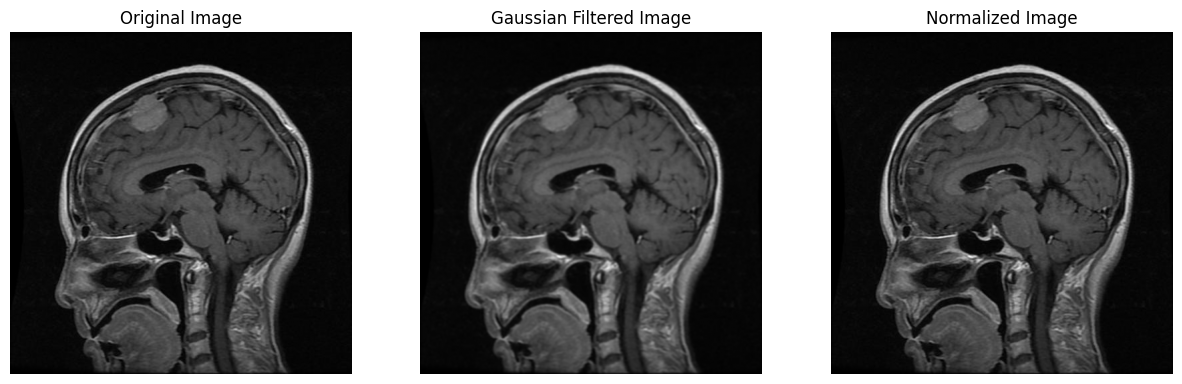

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


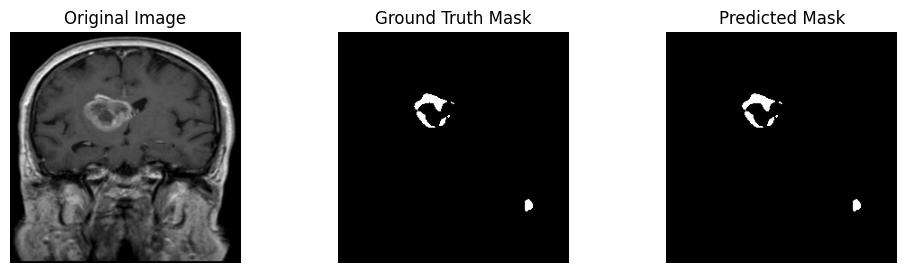

13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 381ms/step - accuracy: 0.9999 - dice_coef: 0.7963 - loss: 0.0062
Dice Coefficient: 0.8024
     Energy    Contrast  Homogeneity  Correlation         Class
0  0.196137  205.824495     0.472598     0.935780  glioma_tumor
1  0.128124  236.410256     0.419504     0.908185  glioma_tumor
2  0.115167  232.428759     0.401138     0.944875  glioma_tumor
3  0.146205  240.552739     0.441782     0.941575  glioma_tumor
4  0.217356   70.832653     0.536937     0.978425  glioma_tumor
5  0.112895  263.653312     0.398518     0.879932  glioma_tumor
6  0.312496  165.083042     0.569326     0.931159  glioma_tumor
7  0.330896  215.341006     0.584266     0.920589  glioma_tumor
8  0.219595  194.051962     0.481877     0.899266  glioma_tumor
9  0.099020  161.932595     0.424418     0.889413  glioma_tumor
         Energy    Contrast  Homogeneity  Correlation            Class
10828  0.041576  228.855866     0.217983     0.914861  pituitary_tumor
10829  0.089890  246.659819     0.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       4,735,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,828,868 (18.42 MB)

 Trainable params: 4,828,868 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

model saved to:/content/drive/MyDrive/ICNN.pkl
Accuracy: 99.72%
Precision : 1.00
Recall : 1.00
F1 Score : 1.00
Confusion matrix


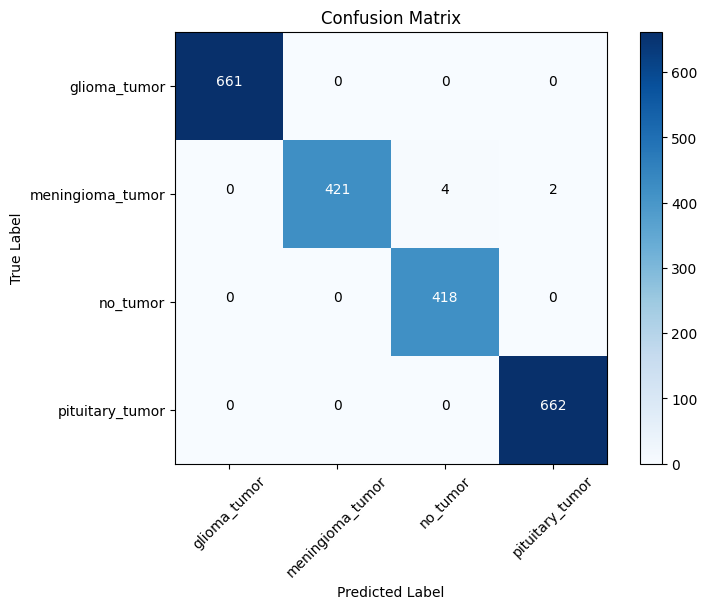

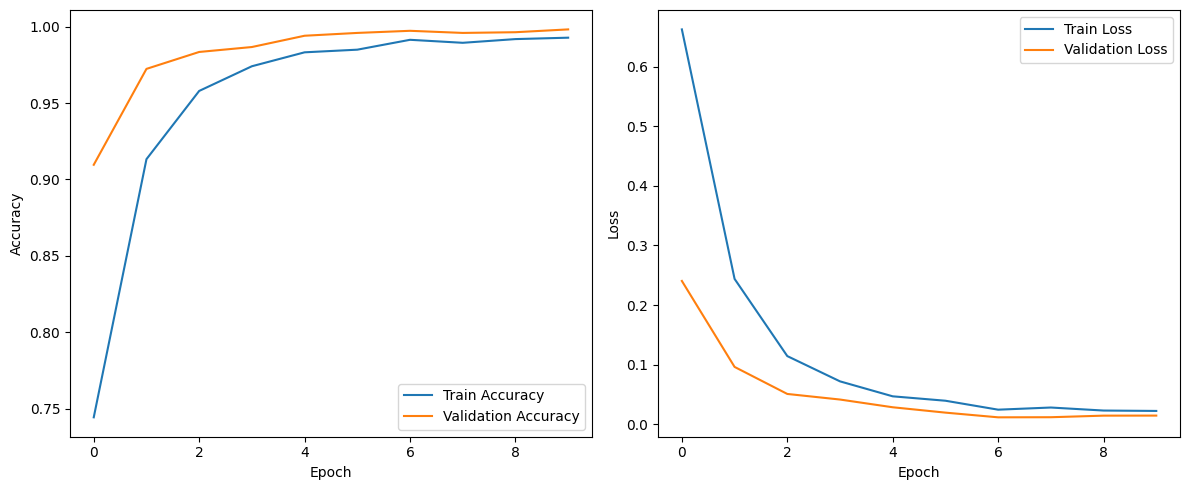

In [ ]:

#library
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score,recall_score,f1_score
import random
import matplotlib.pyplot as plt
import os
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical
from scipy.stats import kurtosis
from PIL import Image
import cv2
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import pandas as pd
from tensorflow.keras.utils import Sequence
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dropout
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report,accuracy_score
import itertools
import pickle
from scipy import signal
from tensorflow.keras import Model
import tensorflow.keras.backend as K
from skimage.feature import graycomatrix,graycoprops
import warnings
warnings.filterwarnings('ignore')

CLASS_TYPES = ['glioma_tumor','meningioma_tumor','no_tumor','pituitary_tumor']
USER_PATH= r"/content/drive/MyDrive/dataset"           #normal dataset path
USER_PATH_= r"/content/drive/MyDrive/segmented_mask"      #mask dataset path
train_image_path=os.path.join(USER_PATH,'Training')
train_mask_path=os.path.join(USER_PATH_,'Training')
test_image_path=os.path.join(USER_PATH,'Testing')
test_mask_path=os.path.join(USER_PATH_,'Testing')
model_dir=r"/content/drive/MyDrive" #path to save segmentation model
os.makedirs(model_dir,exist_ok=True)
model_path=os.path.join(model_dir,"/content/drive/MyDrive/Attention_U-Net.h5")  #segmentation model path
model_file=os.path.join(USER_PATH,r"/content/drive/MyDrive/ICNN.pkl")  #classification model path

#Preprocess
def get_first_image(train_image_path):
    class_folders=sorted(os.listdir(train_image_path))
    if not class_folders:
        raise FileNotFoundError("No directory.")
    path=os.path.join(train_image_path,class_folders[1])
    images=sorted(os.listdir(path))
    if not images:
        raise FileNotFoundError(f"No images found in {path}")
    image_path=os.path.join(path,images[1])
    return image_path
image_path=get_first_image(train_image_path)
image=cv2.imread(image_path)
if image is None:
    raise FileNotFoundError(f"Failed{image_path}")
gray_image=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
#Normalizing
normalized_image=gray_image.astype(np.float32)/255.0
#Gaussian filter
def gaussian_kernels(size=5,sigma=1):
    if size % 2 == 0:
        raise ValueError("Kernel mismatch")
    lower=-int(size//2)
    y,x=np.mgrid[lower:lower+size,lower:lower+size]
    kernel=(1/(2*np.pi*sigma**2))*np.exp(-(x**2+y**2)/(2*sigma**2))
    return kernel/kernel.sum()
def gaussian_filter(image,kernel_size=5,sigma=1):
    kernel=gaussian_kernels(size=kernel_size,sigma=sigma)
    filtered_image=signal.convolve2d(image,kernel,mode='same',boundary='fill',fillvalue=0)
    return filtered_image
filtered_image=gaussian_filter(normalized_image,kernel_size=5,sigma=1)
filtered_image=np.clip(filtered_image*255,0,255).astype(np.uint8)
fig,ax=plt.subplots(1,3,figsize=(15,5))
ax[0].imshow(gray_image,cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(filtered_image,cmap='gray')
ax[1].set_title('Gaussian Filtered Image')
ax[1].axis('off')
ax[2].imshow(normalized_image,cmap='gray')
ax[2].set_title('Normalized Image')
ax[2].axis('off')
plt.show()

#Attention U-Net
def attention_block(x,g,inter_channel):
    theta_x=layers.Conv2D(inter_channel,(1,1),padding='same')(x)
    phi_g=layers.Conv2D(inter_channel,(1,1),padding='same')(g)
    add=layers.Add()([theta_x,phi_g])
    act=layers.Activation('relu')(add)
    psi=layers.Conv2D(1,(1,1),activation='sigmoid',padding='same')(act)
    att=layers.Multiply()([x,psi])
    return att
def attention_unet(input_size=(256,256,3)):
    inputs=layers.Input(input_size)
    # Encoder
    c1=layers.Conv2D(64,(3,3),activation='relu',padding='same')(inputs)
    c1=layers.Conv2D(64,(3,3),activation='relu',padding='same')(c1)
    p1=layers.MaxPooling2D((2,2))(c1)
    c2=layers.Conv2D(128,(3,3),activation='relu',padding='same')(p1)
    c2=layers.Conv2D(128,(3,3),activation='relu',padding='same')(c2)
    p2=layers.MaxPooling2D((2,2))(c2)
    c3=layers.Conv2D(256,(3,3),activation='relu',padding='same')(p2)
    c3=layers.Conv2D(256,(3,3),activation='relu',padding='same')(c3)
    p3=layers.MaxPooling2D((2,2))(c3)
    c4=layers.Conv2D(512,(3,3),activation='relu',padding='same')(p3)
    c4=layers.Conv2D(512,(3,3),activation='relu',padding='same')(c4)
    # Decoder
    u1=layers.UpSampling2D((2,2))(c4)
    u1=layers.Conv2D(256,(2,2),activation='relu',padding='same')(u1)
    att1=attention_block(c3,u1,256)
    u1=layers.concatenate([u1,att1])
    c5=layers.Conv2D(256,(3,3),activation='relu',padding='same')(u1)
    c5=layers.Conv2D(256,(3,3),activation='relu',padding='same')(c5)
    u2=layers.UpSampling2D((2,2))(c5)
    u2=layers.Conv2D(128,(2,2),activation='relu',padding='same')(u2)
    att2=attention_block(c2,u2,128)
    u2=layers.concatenate([u2,att2])
    c6=layers.Conv2D(128,(3,3),activation='relu',padding='same')(u2)
    c6=layers.Conv2D(128,(3,3),activation='relu',padding='same')(c6)
    u3=layers.UpSampling2D((2,2))(c6)
    u3=layers.Conv2D(64,(2,2),activation='relu',padding='same')(u3)
    att3=attention_block(c1,u3,64)
    u3=layers.concatenate([u3,att3])
    c7=layers.Conv2D(64,(3,3),activation='relu',padding='same')(u3)
    c7=layers.Conv2D(64,(3,3),activation='relu',padding='same')(c7)
    outputs=layers.Conv2D(1,(1,1),activation='sigmoid')(c7)
    model=Model(inputs,outputs)
    return model
def load_images_and_masks(image_root_folder,mask_root_folder,target_size=(256,256)):
    images,masks=[],[]
    for subfolder in os.listdir(image_root_folder):
        image_folder=os.path.join(image_root_folder,subfolder)
        mask_folder=os.path.join(mask_root_folder,subfolder)
        if not os.path.isdir(image_folder) or not os.path.isdir(mask_folder):
            continue
        for image_name in os.listdir(image_folder):
            image_path=os.path.join(image_folder,image_name)
            mask_path=os.path.join(mask_folder,image_name)
            if not os.path.exists(mask_path):
                continue
            image=cv2.imread(image_path,cv2.IMREAD_COLOR)
            if image is None:
                continue
            image=cv2.resize(image,target_size)/255.0
            images.append(image)
            mask=cv2.imread(mask_path,cv2.IMREAD_GRAYSCALE)
            if mask is None:
                continue
            mask=cv2.resize(mask,target_size)
            mask=(mask>127).astype(np.float32)
            masks.append(mask)
    images=np.array(images,dtype=np.float32)
    masks=np.array(masks,dtype=np.float32).reshape(-1,target_size[0],target_size[1],1)
    return images,masks
X_train,Y_train=load_images_and_masks(train_image_path,train_mask_path)
X_test,Y_test=load_images_and_masks(test_image_path,test_mask_path)
if os.path.exists(model_path):
    unet_model=tf.keras.models.load_model(model_path)
else:
    unet_model=attention_unet()
    unet_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
    unet_model.fit(X_train,Y_train,validation_split=0.2,epochs=50,batch_size=8)
    unet_model.save(model_path)
    print(f"Model saved:{model_path}")
def dis(images,masks,target_class=1):
    selected_images=[]
    selected_masks=[]
    for img, mask in zip(images,masks):
        if np.any(mask==target_class):
            selected_images.append(img)
            selected_masks.append(mask)
    return np.array(selected_images),np.array(selected_masks)
X_test_filtered,Y_test_filtered=dis(X_test,Y_test,target_class=1)
if len(X_test_filtered)==0:
    print("No test samples")
else:
    num_samples_to_plot=1
    sample_image=X_test_filtered[:num_samples_to_plot]
    sample_mask=Y_test_filtered[:num_samples_to_plot]
    def plot_results(model,input_images,true_masks):
        predictions=model.predict(input_images)
        predictions=(predictions>0.5).astype(np.uint8)
        num_samples=len(input_images)
        plt.figure(figsize=(12,num_samples*3))
        for i in range(num_samples):
            plt.subplot(num_samples,3,i*3+1)
            plt.imshow(input_images[i])
            plt.title("Original Image")
            plt.axis("off")
            plt.subplot(num_samples,3,i*3+2)
            plt.imshow(true_masks[i].squeeze(),cmap="gray")
            plt.title("Ground Truth Mask")
            plt.axis("off")
            plt.subplot(num_samples,3,i*3+3)
            plt.imshow(predictions[i].squeeze(),cmap="gray")
            plt.title("Predicted Mask")
            plt.axis("off")
        plt.show()
    plot_results(unet_model,sample_image,sample_mask)
def dice_coef(y_true,y_pred,smooth=1):
    y_true_f=K.flatten(y_true)
    y_pred_f=K.flatten(y_pred)
    intersection=K.sum(y_true_f*y_pred_f)
    return (2.*intersection+smooth)/(K.sum(y_true_f)+K.sum(y_pred_f)+smooth)
unet_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy',dice_coef])
loss,accuracy,dice=unet_model.evaluate(X_test,Y_test,verbose=1)
print(f"Dice Coefficient: {dice:.4f}")

#IGLCM
img_names,img_array,labels=[],[],[]
for label in CLASS_TYPES:
    folder_path=os.path.join(train_image_path,label)
    images=os.listdir(folder_path)
    for img in images:
        img_path=os.path.join(folder_path,img)
        image=cv2.imread(img_path)
        if image is None:
            print(f"Warning: Unable to read image {img_path}. Skipping.")
            continue
        image_rgb=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
        image_resized=cv2.resize(image_rgb,(144,144),interpolation=cv2.INTER_AREA)
        img_names.append(img)
        img_array.append(image_resized)
        labels.append(label)
img_array=np.array(img_array,dtype='float32')/255
labels=np.array(labels)
def feature_extractor(dataset,labels):
    image_dataset=pd.DataFrame()
    label_list=[]
    for image in range(dataset.shape[0]):
        df=pd.DataFrame()
        gray_img=cv2.cvtColor((dataset[image]*255).astype('uint8'),cv2.COLOR_RGB2GRAY)
        GLCM=graycomatrix(gray_img,[1],[0],symmetric=True,normed=True)
        df['Energy']=graycoprops(GLCM,'energy')[0]
        df['Contrast']=graycoprops(GLCM,'contrast')[0]
        df['Homogeneity']=graycoprops(GLCM,'homogeneity')[0]
        df['Correlation']=graycoprops(GLCM,'correlation')[0]
        label_list.append(labels[image])
        image_dataset=pd.concat([image_dataset,df],ignore_index=True)
    image_dataset['Class']=label_list
    return image_dataset
X_train=feature_extractor(img_array,labels)
print(X_train.head(10))
print(X_train.tail(10))

#ARPBCO
def fn(x):
    return np.sum(x ** 2)
def pop(pop_size,dim,lower_bound,upper_bound):
    return np.random.uniform(lower_bound,upper_bound,(pop_size,dim))
def fitness(cost):
    return 1/(1+cost) if cost>=0 else 1+abs(cost)
def neighborhood_search(solution,lower_bound,upper_bound):
    new_solution=np.copy(solution)
    idx=np.random.randint(len(solution))
    phi=np.random.uniform(-1,1)
    new_solution[idx]+=phi*(new_solution[idx]-np.random.uniform(lower_bound,upper_bound))
    new_solution=np.clip(new_solution,lower_bound,upper_bound)
    return new_solution
def calculate_probabilities(fitness_values):
    total_fitness=sum(fitness_values)
    return [fit/total_fitness if total_fitness!=0 else 0 for fit in fitness_values]
def artificial_bee_colony(pop_size,dim,lower_bound,upper_bound,max_iterations,objective_function):
    employed_bees=pop_size//2
    onlooker_bees=employed_bees
    population=pop(pop_size,dim,lower_bound,upper_bound)
    costs=np.array([objective_function(sol) for sol in population])
    fitness_values=np.array([fitness(cost) for cost in costs])
    best_index=np.argmin(costs)
    best_solution=population[best_index].copy()
    best_cost=costs[best_index]
    iteration=0
    while iteration<max_iterations:
        for i in range(employed_bees):
            new_solution=neighborhood_search(population[i],lower_bound,upper_bound)
            new_cost=objective_function(new_solution)
            if new_cost<costs[i]:
                population[i]=new_solution
                costs[i]=new_cost
                fitness_values[i]=fitness(new_cost)
                if new_cost<best_cost:
                    best_solution=new_solution.copy()
                    best_cost=new_cost
        probabilities=calculate_probabilities(fitness_values)
        for _ in range(onlooker_bees):
            selected_index=np.random.choice(range(pop_size),p=probabilities)
            new_solution=neighborhood_search(population[selected_index],lower_bound,upper_bound)
            new_cost=objective_function(new_solution)
            if new_cost<costs[selected_index]:
                population[selected_index]=new_solution
                costs[selected_index]=new_cost
                fitness_values[selected_index]=fitness(new_cost)
                if new_cost<best_cost:
                    best_solution=new_solution.copy()
                    best_cost=new_cost
        worst_index=np.argmax(costs)
        if np.random.rand()<0.1:
            population[worst_index]=np.random.uniform(lower_bound,upper_bound,dim)
            costs[worst_index]=objective_function(population[worst_index])
            fitness_values[worst_index]=fitness(costs[worst_index])
            if costs[worst_index]<best_cost:
                best_solution=population[worst_index].copy()
                best_cost=costs[worst_index]
        iteration+=1
    return best_solution,best_cost
class RedPiranhaOptimization:
    def __init__(self,fitness_function,dim,bounds,iterations=100):
        self.fitness_function=fitness_function
        self.dim=dim
        self.bounds=bounds
        self.iterations=iterations
    def update_position(self,individual,best,alpha=0.1,beta=0.1):
        r1=np.random.rand(self.dim)
        new_position=individual+alpha*r1*(best-individual)+beta*(np.random.rand(self.dim)-0.5)
        return np.clip(new_position,self.bounds[0],self.bounds[1])
    def optimize(self,initial_solution):
        best_solution=np.copy(initial_solution)
        best_fitness=self.fitness_function(best_solution)
        population=best_solution+np.random.uniform(-0.1,0.1,(10,self.dim))
        population=np.clip(population,self.bounds[0],self.bounds[1])
        fitnesses=np.array([self.fitness_function(ind) for ind in population])
        idx=np.argmin(fitnesses)
        if fitnesses[idx]<best_fitness:
            best_solution=population[idx].copy()
            best_fitness=fitnesses[idx]
        for _ in range(self.iterations):
            for i in range(len(population)):
                new_position=self.update_position(population[i],best_solution)
                new_fit=self.fitness_function(new_position)
                if new_fit<fitnesses[i]:
                    population[i]=new_position
                    fitnesses[i]=new_fit
                    if new_fit<best_fitness:
                        best_solution=new_position.copy()
                        best_fitness=new_fit
        return best_solution,best_fitness
def ARPBCO(dim,bounds,abc_pop_size=30,abc_iterations=50,rpo_iterations=100,objective_function=fn):
    abc_best_solution,abc_best_cost=artificial_bee_colony(pop_size=abc_pop_size,dim=dim,lower_bound=bounds[0],upper_bound=bounds[1],max_iterations=abc_iterations,objective_function=objective_function)
    rpo=RedPiranhaOptimization(fitness_function=objective_function,dim=dim,bounds=bounds,iterations=rpo_iterations)
    hybrid_best_solution,hybrid_best_cost=rpo.optimize(abc_best_solution)
    return hybrid_best_solution,hybrid_best_cost
dim=10
bounds=(-5.12,5.12)
best_solution,best_cost=ARPBCO(dim=dim,bounds=bounds,abc_pop_size=30,abc_iterations=50,rpo_iterations=100,objective_function=fn)
np.random.seed(42)
data=[]
classes=sorted([d for d in os.listdir(train_image_path) if os.path.isdir(os.path.join(train_image_path,d))])
for label in classes:
    class_dir=os.path.join(train_image_path,label)
    for fname in os.listdir(class_dir):
        if fname.lower().endswith(('.png','.jpg','.jpeg')):
            data.append({
                'filepath':os.path.join(class_dir,fname),
                'label':label
            })
df=pd.DataFrame(data)
print("DataFrame",df.head())
train_df,val_df=train_test_split(df,test_size=0.2,stratify=df['label'],random_state=42)
print("Train samples:",len(train_df))
print("test samples:",len(val_df))

#ICNN
class ICNN(Sequence):
    def __init__(self,df,class_names,batch_size,img_height,img_width,shuffle=True):
        self.df=df.reset_index(drop=True)
        self.batch_size=batch_size
        self.img_height=img_height
        self.img_width=img_width
        self.class_names=class_names
        self.num_classes=len(class_names)
        self.shuffle=shuffle
        self.on_epoch_end()
    def __len__(self):
        return int(np.ceil(len(self.df)/self.batch_size))
    def on_epoch_end(self):
        self.indexes=np.arange(len(self.df))
        if self.shuffle:
            np.random.shuffle(self.indexes)
    def __getitem__(self,index):
        batch_indexes=self.indexes[index*self.batch_size:(index+1)*self.batch_size]
        batch_df=self.df.iloc[batch_indexes]
        images=[]
        labels=[]
        for _,row in batch_df.iterrows():
            img=cv2.imread(row['filepath'])
            if img is None:
                continue
            img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
            img=cv2.resize(img,(self.img_width,self.img_height))
            img=img.astype('float32')/255.0
            images.append(img)
            label_idx=self.class_names.index(row['label'])
            labels.append(label_idx)
        images=np.array(images)
        labels=to_categorical(labels,num_classes=self.num_classes)
        return images,labels
img_height,img_width=150,150
batch_size=32
class_names=classes
train_generator=ICNN(train_df,class_names,batch_size,img_height,img_width,shuffle=True)
val_generator=ICNN(val_df,class_names,batch_size,img_height,img_width,shuffle=False)
model=Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(img_height,img_width,3)),
    MaxPooling2D(2,2),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(len(class_names),activation='softmax')
])
optimizer,_='adam',ARPBCO
model.compile(optimizer=optimizer,loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()
early_stopping=EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)
#history=model.fit(train_generator,validation_data=val_generator,epochs=20,callbacks=[checkpoint,early_stopping])
#artifacts={'history':history.history,'accuracy':accuracy_val,'precision':precision_val,'recall':recall_val,'f1':f1_val,'classification_report':class_report,'confusion_matrix':cm,'class_names': class_names}
#with open(artifacts_file,'wb') as f:
 #   pickle.dump(artifacts,f)
print(f"model saved to:{model_file}")
with open(model_file,'rb') as f:
    loaded_artifacts=pickle.load(f)
print("Accuracy: {:.2f}%".format(loaded_artifacts['accuracy']*100))
print("Precision : {:.2f}".format(loaded_artifacts['precision']))
print("Recall : {:.2f}".format(loaded_artifacts['recall']))
print("F1 Score : {:.2f}".format(loaded_artifacts['f1']))
def plot_confusion_matrix(cm,classes,normalize=False,title='Confusion Matrix',cmap=plt.cm.Blues):
    if normalize:
        cm=cm.astype('float')/cm.sum(axis=1)[:,np.newaxis]
    else:
        print("Confusion matrix")
    plt.figure(figsize=(8,6))
    plt.imshow(cm,interpolation='nearest',cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks=np.arange(len(classes))
    plt.xticks(tick_marks,classes,rotation=45)
    plt.yticks(tick_marks,classes)
    fmt='.2f' if normalize else 'd'
    thresh=cm.max()/2.0
    for i,j in itertools.product(range(cm.shape[0]),range(cm.shape[1])):
        plt.text(j,i,format(cm[i,j],fmt),
                 horizontalalignment="center",
                 color="white" if cm[i,j]>thresh else "black")
    plt.tight_layout()
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
plot_confusion_matrix(loaded_artifacts['confusion_matrix'],classes=loaded_artifacts['class_names'],normalize=False)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(loaded_artifacts['history']['accuracy'],label='Train Accuracy')
plt.plot(loaded_artifacts['history']['val_accuracy'],label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.subplot(1,2,2)
plt.plot(loaded_artifacts['history']['loss'],label='Train Loss')
plt.plot(loaded_artifacts['history']['val_loss'],label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()
